In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform

# 한국어 폰트 설정
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 8
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['legend.loc'] = 'upper center'

# 데이터 로드
df = pd.read_csv('UniversalBank.csv')
print(f"데이터 로드 완료: {df.shape[0]}행 × {df.shape[1]}열")

데이터 로드 완료: 5000행 × 10열


In [2]:
# 데이터 구조 확인
print("=== Shape ===")
print(df.shape)
print("\n=== Dtypes ===")
print(df.dtypes)
print("\n=== 처음 5행 ===")
df.head()

=== Shape ===
(5000, 10)

=== Dtypes ===
ID              int64
Age             int64
Experience      int64
Income          int64
Family          int64
CCAvg         float64
Education       int64
CDAccount      object
Mortgage        int64
PLoan          object
dtype: object

=== 처음 5행 ===


,ID,Age,Experience,Income,Family,CCAvg,Education,CDAccount,Mortgage,PLoan
0,1,25,1,49,4,1.6,1,No,0,No
1,2,45,19,34,3,1.5,1,No,0,No
2,3,39,15,11,1,1.0,1,No,0,No
3,4,35,9,100,1,2.7,2,No,0,No
4,5,35,8,45,4,1.0,2,No,0,No


In [3]:
# 결측값 현황
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'결측수': missing, '결측률(%)': missing_pct})
print("=== 결측값 현황 ===")
result = missing_df[missing_df['결측수'] > 0].sort_values('결측률(%)', ascending=False)
if result.empty:
    print("결측값 없음")
else:
    print(result)

=== 결측값 현황 ===
결측값 없음


In [4]:
# 수치형 기술통계
print("=== 수치형 기술통계 ===")
df.describe()

=== 수치형 기술통계 ===


,ID,Age,Experience,Income,Family,CCAvg,Education,Mortgage
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,2.396400,1.937938,1.881000,56.498800
std,1443.520003,11.463166,11.467954,46.033729,1.147663,1.747659,0.839869,101.713802
min,1.000000,23.000000,-3.000000,8.000000,1.000000,0.000000,1.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,1.000000,0.700000,1.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,2.000000,1.500000,2.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,3.000000,2.500000,3.000000,101.000000
max,5000.000000,67.000000,43.000000,224.000000,4.000000,10.000000,3.000000,635.000000


In [5]:
# 범주형 기술통계
cat_cols = df.select_dtypes(include='object').columns
if len(cat_cols) > 0:
    for col in cat_cols:
        print(f"\n=== {col} (unique: {df[col].nunique()}) ===")
        print(df[col].value_counts().head(10))
else:
    print("범주형 컬럼 없음")


=== CDAccount (unique: 2) ===
CDAccount
No     4698
Yes     302
Name: count, dtype: int64

=== PLoan (unique: 2) ===
PLoan
No     4520
Yes     480
Name: count, dtype: int64


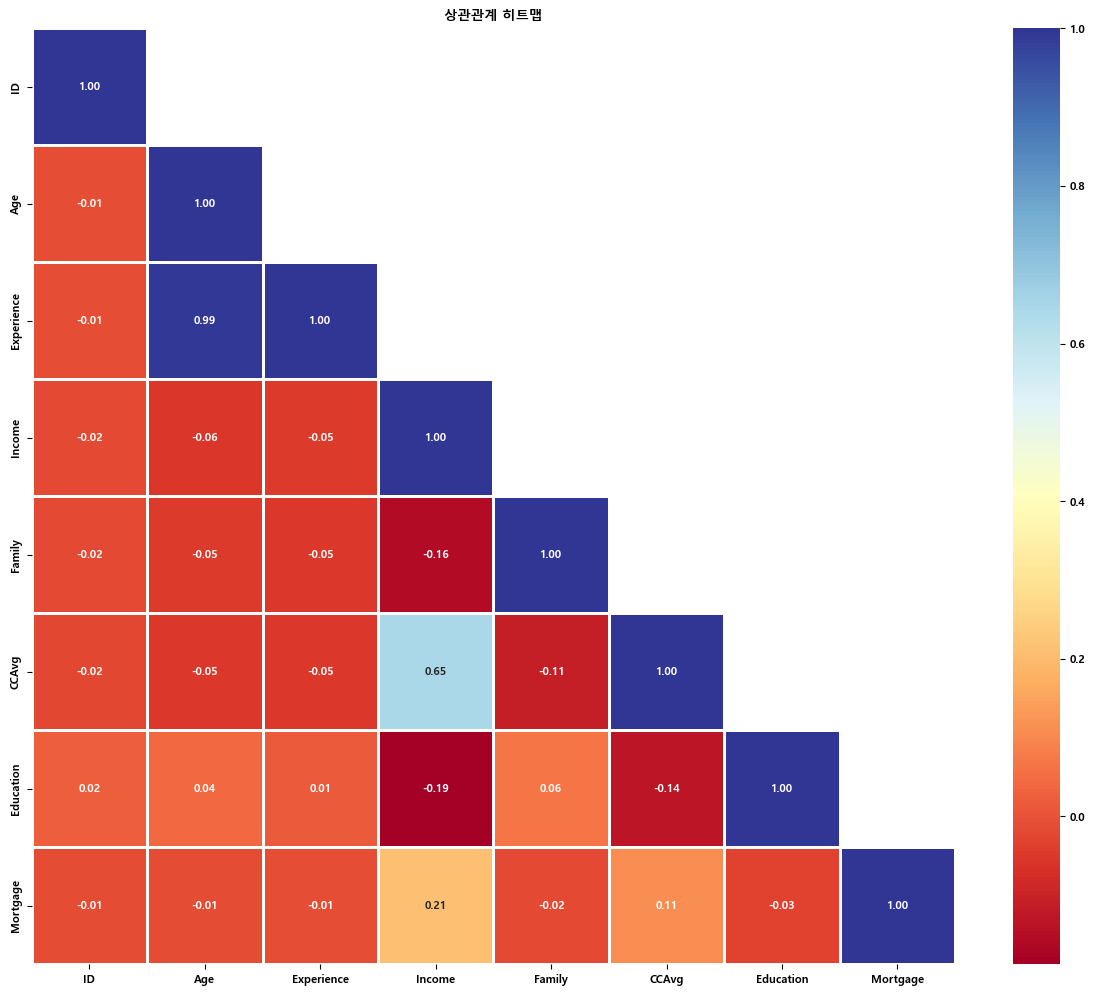

In [6]:
# 상관관계 히트맵 (수치형 변수)
num_cols = df.select_dtypes(include=np.number).columns
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, mask=mask, cmap='RdYlBu', annot=True, fmt='.2f',
            annot_kws={'fontweight': 'bold', 'fontsize': 8},
            linewidth=1, ax=ax)
ax.set_title('상관관계 히트맵', fontdict={'fontweight': 'bold'})
plt.tight_layout()
plt.show()

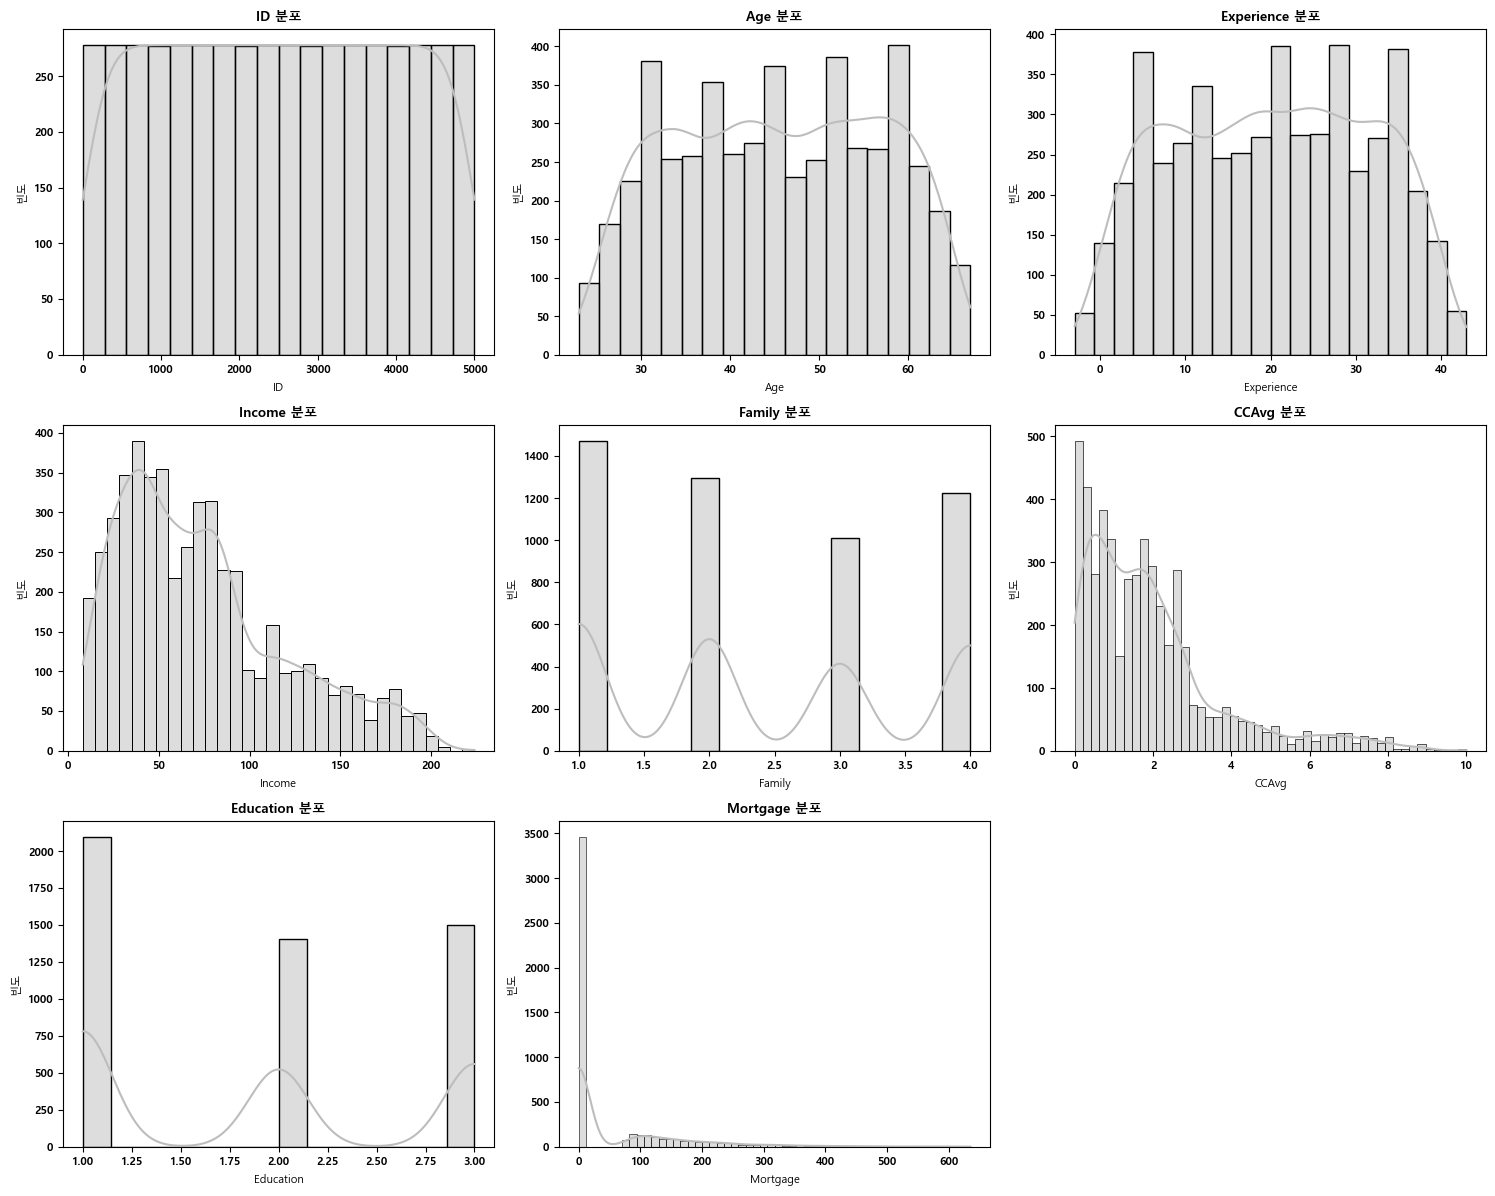

In [7]:
# 수치형 변수 분포 히스토그램 (대용량: 전체 사용, kde=True)
num_cols_list = list(df.select_dtypes(include=np.number).columns)
n_cols = 3
n_rows = (len(num_cols_list) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols_list):
    sns.histplot(df[col], kde=True, color='#BDBDBD', ax=axes[i])
    axes[i].set_title(f'{col} 분포', fontdict={'fontweight': 'bold'})
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('빈도')

# 남은 서브플롯 숨기기
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

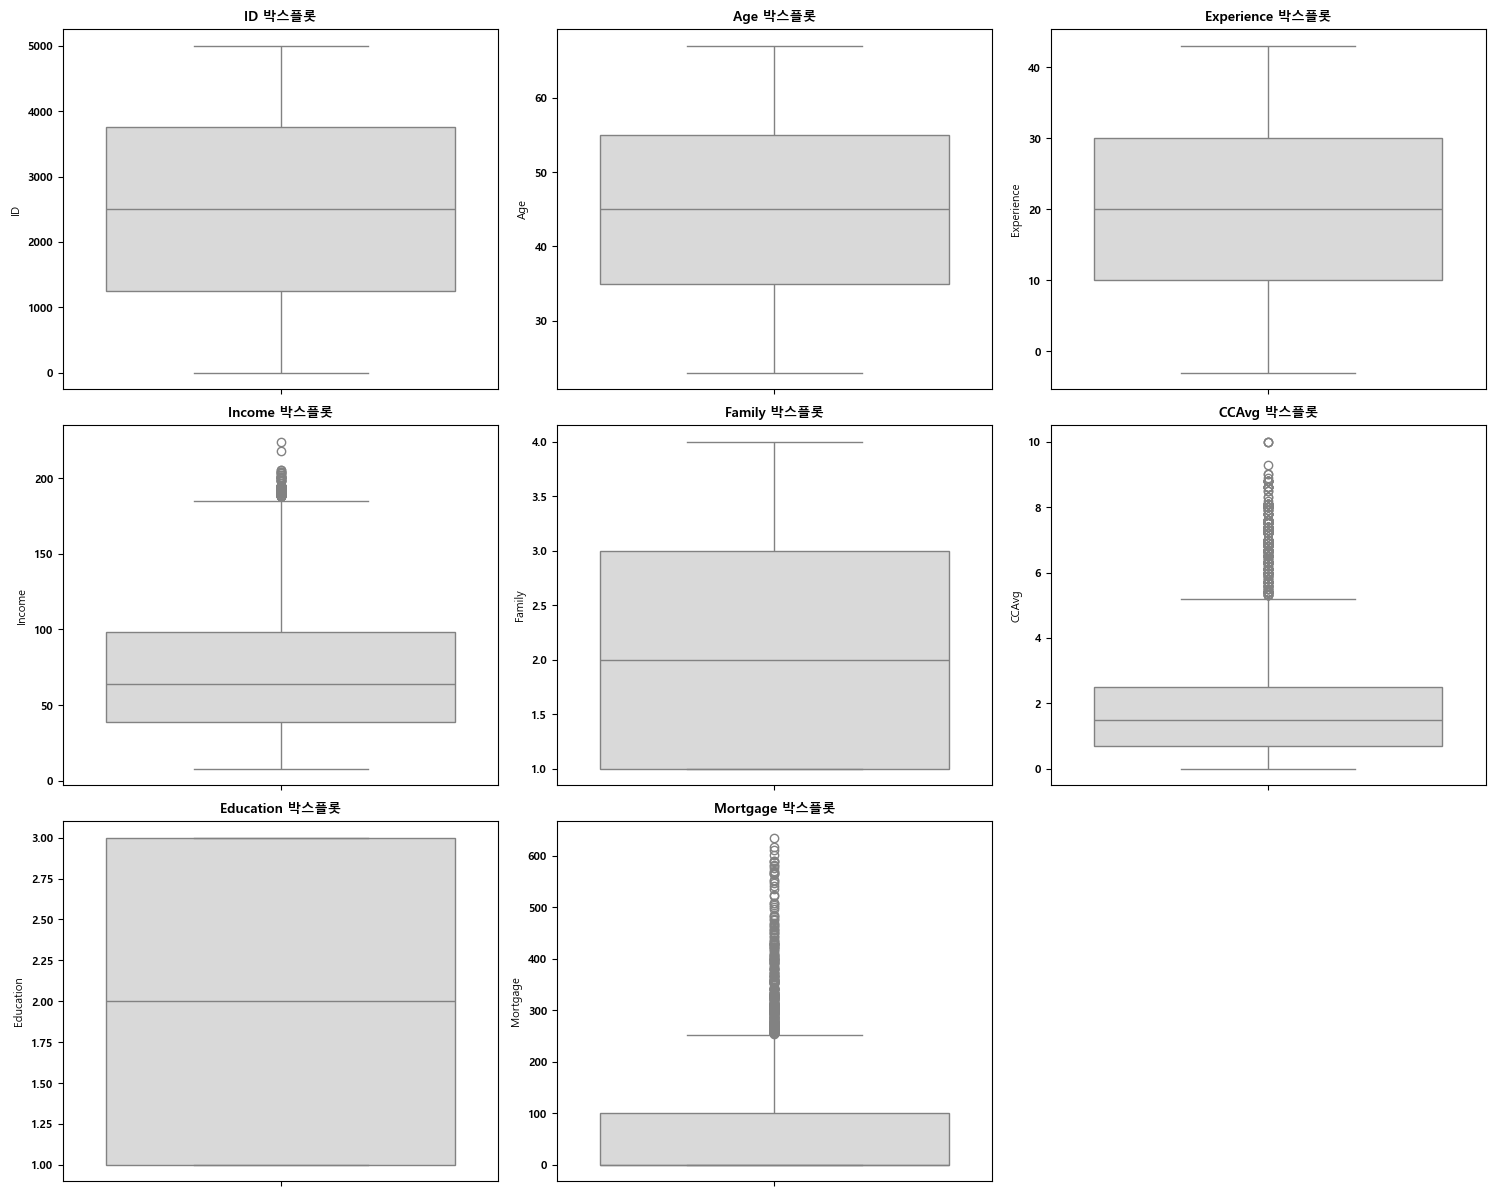

In [8]:
# 수치형 변수 박스플롯 (이상치 확인)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols_list):
    sns.boxplot(data=df, y=col, color='#D9D9D9', ax=axes[i])
    axes[i].set_title(f'{col} 박스플롯', fontdict={'fontweight': 'bold'})
    axes[i].set_ylabel(col)

# 남은 서브플롯 숨기기
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()